# EVAC Part 1

In [227]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random
from deap import base, creator, tools, algorithms
from scipy.stats import mannwhitneyu, shapiro, levene

# DATA

In [228]:
# Food,Cost,Protein,Fat,Carbohydrate,Calories
data = [
    ["Bread",2.0,4.0,1.0,15.0,90],

    ["Milk",3.5,8.0,5.0,11.7,120],

    ["Cheese",8.0,7.0,9.0,0.4,106],

    ["Potato",1.5,1.3,0.1,22.6,97],

    ["Fish",11.0,8.0,7.0,0.0,130],

    ["Yoghurt",1.0,9.2,1.0,17.0,180],
]

# Constraints
CALORIES_MIN = 300
PROTEIN_MAX = 10
CARBS_MIN = 10
FAT_MIN = 8
FISH_MIN = 0.5
MILK_MAX = 1.0

# EVOLUTIONARY ALGORITHM

In [229]:
# GA Functions
def evalDiet(individual, penalty=100):
    '''
    Evaluate the diet by calculating total cost and checking constraints.
    * param individual: A list of amounts for each food item.
    * return: A tuple containing the total cost (or a high cost if constraints are violated).
    '''
    total_cost = 0
    total_protein = 0
    total_fat = 0
    total_carbs = 0
    total_calories = 0

    # Check for negative amounts and return high cost if found
    total_cost += sum(abs(amt) for amt in individual if amt < 0) * penalty

    # Calculate total cost and nutrients
    for i in range(len(data)):
        amount = max(0, individual[i]) # Ensure no negative amounts
        total_cost += amount * data[i][1]
        total_protein += amount * data[i][2]
        total_fat += amount * data[i][3]
        total_carbs += amount * data[i][4]
        total_calories += amount * data[i][5]

    # Check constraints and add penalties
    total_cost += penalty * (CALORIES_MIN - total_calories) if total_calories < CALORIES_MIN else 0
    total_cost += penalty * (total_protein - PROTEIN_MAX) if total_protein > PROTEIN_MAX else 0
    total_cost += penalty * (CARBS_MIN - total_carbs) if total_carbs < CARBS_MIN else 0
    total_cost += penalty * (FAT_MIN - total_fat) if total_fat < FAT_MIN else 0
    total_cost += penalty * (FISH_MIN - individual[4]) if individual[4] < FISH_MIN else 0
    total_cost += penalty * (individual[1] - MILK_MAX) if individual[1] > MILK_MAX else 0

    return total_cost,

In [230]:
# Genetic algorithm parameters
NGEN = 500
CXPB = 0.8
MUTPB = 0.2
MU = 100
LAMBDA = 200
CX_ALPHA = 1.0
MUT_SIGMA = 0.20
MUT_INDPB = 0.40

# Create fitness and individual
creator.create("Cost", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.Cost)

# Create toolbox and register functions
toolbox = base.Toolbox()
toolbox.register("food_amount", random.uniform, 0, 4) # maximum of 4 servings per food item as 4 of any item would exceed calorie constraints
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.food_amount, n=len(data))
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evalDiet)
toolbox.register("select", tools.selTournament, tournsize=5)
toolbox.register("mate", tools.cxBlend, alpha=CX_ALPHA)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=MUT_SIGMA, indpb=MUT_INDPB)

# Tools setup for statistics and hall of fame
stats = tools.Statistics(key=lambda ind: ind.fitness.values)
logbook = tools.Logbook()
hof = tools.HallOfFame(1)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)
logbook.header = "gen", "avg", "evals", "std", "min", "max"

In [231]:
# Initial population
pop = toolbox.population(LAMBDA)
# Run the genetic algorithm
pop, logbook = algorithms.eaMuPlusLambda(pop, toolbox, MU, LAMBDA, CXPB, MUTPB, NGEN, stats, hof)

gen	nevals	avg    	std    	min    	max    
0  	200   	6632.84	1924.83	1582.32	11260.6
1  	200   	3977.74	1170.23	1410.89	6858.69
2  	200   	2574.8 	898.603	722.693	5411.75
3  	200   	1586.12	658.672	238.148	3363.07
4  	200   	994.004	420.039	238.148	2004.71
5  	200   	582.36 	253.745	152.653	1364.2 
6  	200   	374.36 	156.832	132.725	1179.36
7  	200   	263.318	79.815 	97.3028	495.557
8  	200   	201.798	56.4932	76.981 	315.775
9  	200   	146.122	47.5727	76.981 	280.755
10 	200   	109.709	32.5742	63.5448	201.997
11 	200   	84.911 	18.9233	40.9952	168.151
12 	200   	75.354 	18.7888	29.6811	136.477
13 	200   	67.724 	18.4571	29.6811	133.942
14 	200   	56.1243	13.7678	29.6811	92.9905
15 	200   	46.7049	15.3506	23.6596	130.943
16 	200   	36.4354	11.4675	22.1913	86.8157
17 	200   	28.0242	4.61958	20.8587	47.1919
18 	200   	24.6623	2.88113	19.1747	29.6811
19 	200   	21.9632	1.65644	18.3184	26.4962
20 	200   	20.5989	1.19992	17.2335	23.3055
21 	200   	19.7978	0.991836	17.2335	23.4053
22 	200   

# RESULTS

In [232]:
# Get the best solution and output everything they chose, nutritional content and what cost they expended
best_ind = hof[0]
print("The best individual orders: Bread=%.2f, Milk=%.2f, Cheese=%.2f, Potato=%.2f, Fish=%.2f, Yoghurt=%.2f" % (
    best_ind[0], 
    best_ind[1], 
    best_ind[2], 
    best_ind[3], 
    best_ind[4], 
    best_ind[5]
))  
print("Nutritional content: Protein=%.2f, Fat=%.2f, Carbs=%.2f, Calories=%.2f" % (
    sum(max(0, best_ind[i]) * data[i][2] for i in range(len(data))),
    sum(max(0, best_ind[i]) * data[i][3] for i in range(len(data))),
    sum(max(0, best_ind[i]) * data[i][4] for i in range(len(data))),
    sum(max(0, best_ind[i]) * data[i][5] for i in range(len(data)))
))
print("With cost %s" % (best_ind.fitness.values))

The best individual orders: Bread=0.00, Milk=0.03, Cheese=0.46, Potato=1.86, Fish=0.50, Yoghurt=0.01
Nutritional content: Protein=10.00, Fat=8.00, Carbs=42.74, Calories=300.00
With cost 12.095807810303128


(10.0, 30.0)

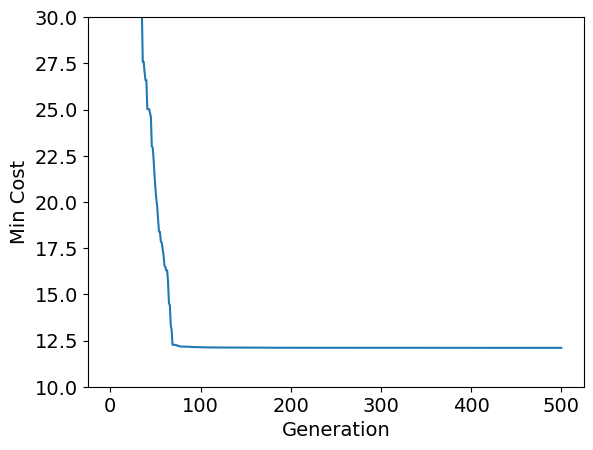

In [220]:
# Get data from logbook
gen = logbook.select("gen")
avgs = logbook.select("avg")
stds = logbook.select("std")
mins = logbook.select("min")

# Plotting
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)
# Choosing min as mean is useless when we have such a large penalty for constaint violation
fig, ax1 = plt.subplots()
line1 = ax1.plot(gen, mins)
ax1.set_xlabel("Generation")
ax1.set_ylabel("Min Cost")
ax1.set_ylim(10, 30)

# Statistical Analysis

## Stage one

In [ ]:
# Create a matrix of parameter values for the screening phase we want 3 of each parameter to get a good coverage of the parameter space, but not too many to be computationally infeasible
screening_matrix = {
    "tournsize": [3, 5, 7],
    "cx_alpha": [0.1, 0.5, 1.0],  
    "mut_sigma": [0.05, 0.2, 0.4],   
    "mut_pb": [0.05, 0.2, 0.4],   
    "mut_indpb": [0.05, 0.2, 0.4],
    "cx_pb": [0.2, 0.4, 0.8],            
}

mu = 100
lambda_ = 200

# Generate all combinations of parameters
from itertools import product
keys, values = zip(*screening_matrix.items())
experiments = [dict(zip(keys, v)) for v in product(*values)]

# Filter out combinations where cx_pb + mut_pb > 1
experiments = [exp for exp in experiments if exp["cx_pb"] + exp["mut_pb"] <= 1]
print(f"Total experiments to run: {len(experiments)}")

results = []
SEEDS = [random.randint(0, 10000) for _ in range(10)]  # Generate 10 random seeds for reproducibility, and so we have the same seeds for each experiment.
# Run experiments
for idx, exp in enumerate(experiments):
    print(f"Running experiment {idx+1}/{len(experiments)} with parameters: {exp}")
    exp_results = []
    for seed in SEEDS:
        random.seed(seed)
        np.random.seed(seed)
        hof.clear() 
        # Update toolbox with current experiment parameters
        toolbox.register("select", tools.selTournament, tournsize=exp["tournsize"])
        toolbox.register("mate", tools.cxBlend, alpha=exp["cx_alpha"])
        toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=exp["mut_sigma"], indpb=exp["mut_indpb"]) # indpb is set to 0.16 to ensure on average one gene is mutated, as we have 6 genes, 1/6 ~ 0.16, mean is set to 0 as we want mutations to be centered around the original value.
        
        # Run the genetic algorithm
        pop = toolbox.population(lambda_)
        pop, logbook = algorithms.eaMuPlusLambda(pop, toolbox, mu, lambda_, exp["cx_pb"], exp["mut_pb"], NGEN, stats, hof, verbose=False)
        
        # Store the best fitness of this run
        best_fitness = hof[0].fitness.values[0]
        exp_results.append(best_fitness)
    results.append((exp, exp_results))

Total experiments to run: 648
Running experiment 1/648 with parameters: {'tournsize': 3, 'cx_alpha': 0.1, 'mut_sigma': 0.05, 'mut_pb': 0.05, 'mut_indpb': 0.05, 'cx_pb': 0.2}
Running experiment 2/648 with parameters: {'tournsize': 3, 'cx_alpha': 0.1, 'mut_sigma': 0.05, 'mut_pb': 0.05, 'mut_indpb': 0.05, 'cx_pb': 0.4}
Running experiment 3/648 with parameters: {'tournsize': 3, 'cx_alpha': 0.1, 'mut_sigma': 0.05, 'mut_pb': 0.05, 'mut_indpb': 0.05, 'cx_pb': 0.8}
Running experiment 4/648 with parameters: {'tournsize': 3, 'cx_alpha': 0.1, 'mut_sigma': 0.05, 'mut_pb': 0.05, 'mut_indpb': 0.2, 'cx_pb': 0.2}
Running experiment 5/648 with parameters: {'tournsize': 3, 'cx_alpha': 0.1, 'mut_sigma': 0.05, 'mut_pb': 0.05, 'mut_indpb': 0.2, 'cx_pb': 0.4}
Running experiment 6/648 with parameters: {'tournsize': 3, 'cx_alpha': 0.1, 'mut_sigma': 0.05, 'mut_pb': 0.05, 'mut_indpb': 0.2, 'cx_pb': 0.8}
Running experiment 7/648 with parameters: {'tournsize': 3, 'cx_alpha': 0.1, 'mut_sigma': 0.05, 'mut_pb': 0.05

In [116]:
processed_rows = []
for exp, seeds_fitness in results:
    clean_scores = [f if isinstance(f, (int, float)) else f[0] for f in seeds_fitness]
    
    row = {
        "tournsize": exp["tournsize"],
        "cx_alpha": exp["cx_alpha"],
        "mut_sigma": exp["mut_sigma"],
        "mut_pb": exp["mut_pb"],
        "mut_indpb": exp["mut_indpb"],
        "cx_pb": exp["cx_pb"],
        "mean_cost": np.mean(clean_scores),
        "std_dev": np.std(clean_scores),
        "best_seed_cost": np.min(clean_scores)
    }
    processed_rows.append(row)

# Convert to pandas DataFrame for rapid automated filtering
df = pd.DataFrame(processed_rows)
df.to_csv("hyperparameter_screening_results.csv", index=False)
print("Data frame successfully compiled and archived!")


Data frame successfully compiled and archived!


In [127]:
# Sort by lowest mean cost across all 10 seeds to find the ultimate robust winner
top_configs = df.sort_values(by="best_seed_cost", ascending=True).head(20)
print("\n--- TOP 20 PERFORMING CONFIGURATIONS ---")
print(top_configs.to_string(index=False))


--- TOP 20 PERFORMING CONFIGURATIONS ---
 tournsize  cx_alpha  mut_sigma  mut_pb  mut_indpb  cx_pb  mean_cost   std_dev  best_seed_cost
         5       1.0       0.20    0.05       0.40    0.8  14.908127  8.370606       12.083912
         5       1.0       0.40    0.20       0.40    0.4  13.440277  2.158157       12.084434
         5       1.0       0.05    0.20       0.05    0.8  12.497021  1.167626       12.085450
         7       1.0       0.40    0.40       0.20    0.4  14.405428  5.914491       12.085904
         3       1.0       0.05    0.05       0.20    0.8  12.218463  0.174851       12.086120
         5       0.5       0.40    0.05       0.40    0.8  14.163480  2.803105       12.087194
         3       1.0       0.05    0.05       0.05    0.8  12.116199  0.032527       12.087575
         5       1.0       0.40    0.05       0.05    0.8  16.787340 13.988521       12.087600
         3       1.0       0.20    0.05       0.05    0.8  12.110973  0.020694       12.087771
        

In [118]:
selection_analysis = df.groupby("tournsize")[["mean_cost", "std_dev"]].mean()
print("\n--- GLOBAL IMPACT OF SELECTION PRESSURE ---")
print(selection_analysis)
mutation_analysis = df.groupby("mut_sigma")[["mean_cost", "std_dev"]].mean()
print("\n--- GLOBAL IMPACT OF MUTATION STEP SIZE ---")
print(mutation_analysis)
cxAlpha_analysis = df.groupby("cx_alpha")[["mean_cost", "std_dev"]].mean()
print("\n--- GLOBAL IMPACT OF CROSSOVER ALPHA ---")
print(cxAlpha_analysis)
mutpb_analysis = df.groupby("mut_pb")[["mean_cost", "std_dev"]].mean()
print("\n--- GLOBAL IMPACT OF MUTATION PROBABILITY ---")
print(mutpb_analysis)
mut_indpb_analysis = df.groupby("mut_indpb")[["mean_cost", "std_dev"]].mean()
print("\n--- GLOBAL IMPACT OF MUTATION INDEPENDENT PROBABILITY ---")
print(mut_indpb_analysis)
cxpb_analysis = df.groupby("cx_pb")[["mean_cost", "std_dev"]].mean()
print("\n--- GLOBAL IMPACT OF CROSSOVER PROBABILITY ---")
print(cxpb_analysis)


--- GLOBAL IMPACT OF SELECTION PRESSURE ---
           mean_cost    std_dev
tournsize                      
3          39.850306  27.296953
5          37.142239  25.512250
7          34.989154  25.701700

--- GLOBAL IMPACT OF MUTATION STEP SIZE ---
           mean_cost    std_dev
mut_sigma                      
0.05       48.450002  37.551837
0.20       32.471062  21.674501
0.40       31.060635  19.284564

--- GLOBAL IMPACT OF CROSSOVER ALPHA ---
          mean_cost    std_dev
cx_alpha                      
0.1       65.585417  45.407749
0.5       26.136926  20.460365
1.0       20.259357  12.642789

--- GLOBAL IMPACT OF MUTATION PROBABILITY ---
        mean_cost    std_dev
mut_pb                      
0.05    55.371252  42.118190
0.20    29.066727  18.830960
0.40    22.651963  13.257479

--- GLOBAL IMPACT OF MUTATION INDEPENDENT PROBABILITY ---
           mean_cost    std_dev
mut_indpb                      
0.05       69.901696  56.270519
0.20       25.524032  16.282973
0.40       16.

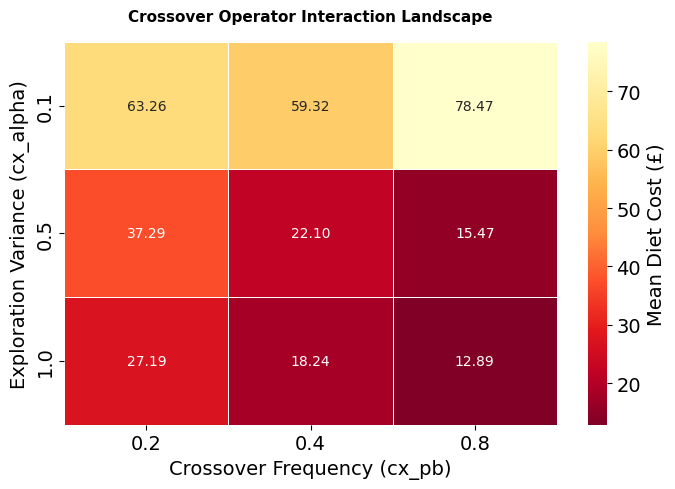

In [120]:
# Pivot the crosover family variables to create a matrix for the heatmap
cx_matrix = df.pivot_table(
    values="mean_cost", 
    index="cx_alpha", 
    columns="cx_pb", 
    aggfunc="mean"
)

# Plotting the heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    cx_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="YlOrRd_r", 
    cbar_kws={'label': 'Mean Diet Cost (£)'},
    linewidths=0.5
)

plt.title("Crossover Operator Interaction Landscape", fontsize=11, fontweight='bold', pad=15)
plt.ylabel("Exploration Variance (cx_alpha)")
plt.xlabel("Crossover Frequency (cx_pb)")
plt.tight_layout()
plt.show()

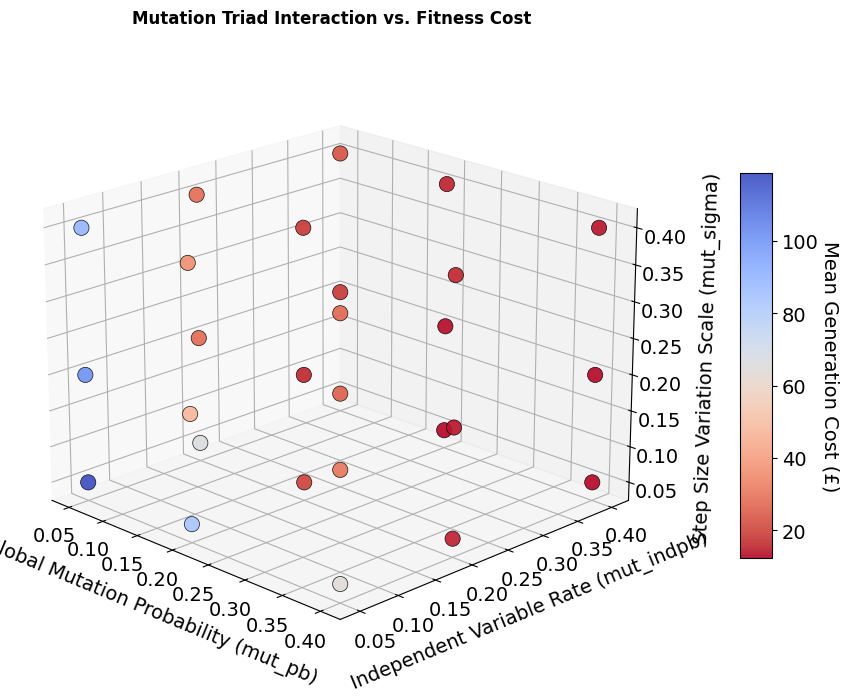

In [ ]:
# 1. Load data and group exclusively by the mutation triad
# This averages out any variation caused by crossover combinations
mut_triad = df.groupby(["mut_pb", "mut_indpb", "mut_sigma"])["mean_cost"].mean().reset_index()

# create a 3D canvas
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points
sc = ax.scatter(
    mut_triad["mut_pb"],
    mut_triad["mut_indpb"],
    mut_triad["mut_sigma"],
    c=mut_triad["mean_cost"],
    cmap="coolwarm_r", 
    s=120,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.9
)

ax.set_title("Mutation Triad Interaction vs. Fitness Cost", fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel("Global Mutation Probability (mut_pb)", labelpad=10)
ax.set_ylabel("Independent Variable Rate (mut_indpb)", labelpad=10)
ax.set_zlabel("Step Size Variation Scale (mut_sigma)", labelpad=10)
cbar = fig.colorbar(sc, ax=ax, shrink=0.6, aspect=12, pad=0.1)
cbar.set_label("Mean Generation Cost (£)", rotation=270, labelpad=15)

ax.view_init(elev=20, azim=-45)

plt.tight_layout()
plt.show()

## Stage 2

## Tournament Size Hypothesis

### Test

In [124]:
FIXED_CX_ALPHA = 1.0
MU = 100
LAMBDA = 200
NGEN = 500
SIGMA = 0.05
INDPB = 0.05
FIXED_CX_PB = 0.8
FIXED_MUT_PB = 0.05

# Generating 100 seeds for high statistical power
HYPOTHESIS_SEEDS = [random.randint(0, 10000) for _ in range(100)]

toolbox = base.Toolbox()
toolbox.register("attr_float", random.uniform, 0, 5)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=6)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evalDiet) 

toolbox.register("mate", tools.cxBlend, alpha=FIXED_CX_ALPHA)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=SIGMA, indpb=INDPB)

setups = {
    "Tournament_3": {"tournsize": 3},
    "Tournament_5": {"tournsize": 5}
}

raw_run_data = []

for name, params in setups.items():
    print(f"Executing 100 seed runs for: {name}...")
    
    toolbox.register("select", tools.selTournament, tournsize=params["tournsize"])
    
    for run_idx, seed in enumerate(HYPOTHESIS_SEEDS):
        random.seed(seed)
        np.random.seed(seed)
        
        pop = toolbox.population(n=MU)
        final_pop, logbook = algorithms.eaMuPlusLambda(
            pop, toolbox, mu=MU, lambda_=LAMBDA, 
            cxpb=FIXED_CX_PB, mutpb=FIXED_MUT_PB, ngen=NGEN, verbose=False
        )
        
        best_ind = tools.selBest(final_pop, 1)[0]
        cost = best_ind.fitness.values[0]
        
        if not np.isnan(cost):
            raw_run_data.append({
                "Setup": name,
                "Seed": seed,
                "Final_Cost": cost
            })

# Save results 
df_hyp = pd.DataFrame(raw_run_data)
df_hyp.to_csv("tournament_variance_results.csv", index=False)
print("Data collection complete. Saved to 'tournament_variance_results.csv'.\n")

Executing 100 seed runs for: Tournament_3...
Executing 100 seed runs for: Tournament_5...
Data collection complete. Saved to 'tournament_variance_results.csv'.



### Statistical Analysis

In [ ]:
t3_scores = df_hyp[df_hyp["Setup"] == "Tournament_3"]["Final_Cost"]
t5_scores = df_hyp[df_hyp["Setup"] == "Tournament_5"]["Final_Cost"]

mean_t3 = np.mean(t3_scores)
mean_t5 = np.mean(t5_scores)
std_t3 = np.std(t3_scores)
std_t5 = np.std(t5_scores)

print(f"Tournament 3 Mean Cost: £{mean_t3:.4f} | Standard Deviation: £{std_t3:.6f}")
print(f"Tournament 5 Mean Cost: £{mean_t5:.4f} | Standard Deviation: £{std_t5:.6f}")
print("-" * 60)

# Normality checks 
_, p_norm_t3 = shapiro(t3_scores)
_, p_norm_t5 = shapiro(t5_scores)
print(f"Tournament 3 Normality p-value: {p_norm_t3:.6f}")
print(f"Tournament 5 Normality p-value: {p_norm_t5:.6f}")
print("-" * 60)

levene_stat, p_val_levene = levene(t3_scores, t5_scores)

print(f"Levene's Test Statistic: {levene_stat:.4f}")
print(f"Calculated p-value (Variance Stability): {p_val_levene:.6f}")

if p_val_levene < 0.05:
    print("\nResult is STATISTICALLY SIGNIFICANT (p < 0.05).")
    if std_t3 < std_t5:
        print("SUCCESS: Tournament Size 3 yields significantly lower standard deviation.")
        print("Hypothesis is SUPPORTED: Lower selection pressure provides a more reliable, stable search.")
    else:
        print("Hypothesis is REJECTED: Tournament Size 5 yields significantly lower standard deviation.")
        print("Higher selection pressure stabilizes the population across different random seeds.")
else:
    print("\nResult is NOT STATISTICALLY SIGNIFICANT (p >= 0.05).")
    print("There is no structural stability difference between tournament sizes 3 and 5.")
    print("The differences in standard deviation observed are purely due to stochastic noise.")

u_stat, p_val_u = mannwhitneyu(t3_scores, t5_scores, alternative='two-sided')

print(f"Mann-Whitney U Statistic: {u_stat}")
print(f"Calculated p-value (Cost Performance): {p_val_u:.6f}")

if p_val_u < 0.05:
    print("\nResult is STATISTICALLY SIGNIFICANT (p < 0.05).")
    if mean_t5 < mean_t3:
        print("SUCCESS: Tournament Size 5 yields significantly lower costs than Tournament Size 3.")
        print("Higher selection pressure is structurally superior for minimizing cost.")
    else:
        print("Tournament Size 3 yields significantly lower costs.")
else:
    print("\nResult is NOT STATISTICALLY SIGNIFICANT (p >= 0.05).")
    print("There is no structural difference in cost performance between the two tournament sizes.")

Tournament 3 Mean Cost: £12.9229 | Standard Deviation: £4.165070
Tournament 5 Mean Cost: £12.8025 | Standard Deviation: £2.937830
------------------------------------------------------------
Tournament 3 Normality p-value: 0.000000
Tournament 5 Normality p-value: 0.000000
------------------------------------------------------------
Levene's Test Statistic: 0.0572
Calculated p-value (Variance Stability): 0.811289

Result is NOT STATISTICALLY SIGNIFICANT (p >= 0.05).
There is no structural stability difference between tournament sizes 3 and 5.
The differences in standard deviation observed are purely due to stochastic noise.
Mann-Whitney U Statistic: 4035.0
Calculated p-value (Cost Performance): 0.018441

Result is STATISTICALLY SIGNIFICANT (p < 0.05).
SUCCESS: Tournament Size 5 yields significantly lower costs than Tournament Size 3.
Higher selection pressure is structurally superior for minimizing cost.


## Mutation Probability Hypothesis

### Test

In [ ]:
FIXED_TOURNSIZE = 5     # Locked based on Stage 2, Test 1
FIXED_CX_ALPHA = 1.0
FIXED_CX_PB = 0.8
SIGMA = 0.2
INDPB = 0.16

MU = 100
LAMBDA = 200
NGEN = 500

# Generating 100 seeds for high statistical power
HYPOTHESIS_SEEDS = [random.randint(0, 10000) for _ in range(100)]

toolbox = base.Toolbox()
toolbox.register("attr_float", random.uniform, 0, 5)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=6)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evalDiet) 

toolbox.register("select", tools.selTournament, tournsize=FIXED_TOURNSIZE)
toolbox.register("mate", tools.cxBlend, alpha=FIXED_CX_ALPHA)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=SIGMA, indpb=INDPB)

setups = {
    "Mutation_05": {"mut_pb": 0.05},
    "Mutation_20": {"mut_pb": 0.20}
}

raw_run_data = []

for name, params in setups.items():
    print(f"Executing 100 seed runs for: {name}...")
    
    for run_idx, seed in enumerate(HYPOTHESIS_SEEDS):
        random.seed(seed)
        np.random.seed(seed)
        
        pop = toolbox.population(n=MU)
        final_pop, logbook = algorithms.eaMuPlusLambda(
            pop, toolbox, mu=MU, lambda_=LAMBDA, 
            cxpb=FIXED_CX_PB, mutpb=params["mut_pb"], ngen=NGEN, verbose=False
        )
        
        best_ind = tools.selBest(final_pop, 1)[0]
        cost = best_ind.fitness.values[0]
        
        if not np.isnan(cost):
            raw_run_data.append({
                "Setup": name,
                "Seed": seed,
                "Final_Cost": cost
            })

df_mut = pd.DataFrame(raw_run_data)
df_mut.to_csv("mutation_stability_results.csv", index=False)
print("Data collection complete. Saved to 'mutation_stability_results.csv'.\n")

Executing 100 seed runs for: Mutation_05...


AssertionError: The sum of the crossover and mutation probabilities must be smaller or equal to 1.0.

### Statistical Analysis

In [234]:
m05_scores = df_mut[df_mut["Setup"] == "Mutation_05"]["Final_Cost"]
m20_scores = df_mut[df_mut["Setup"] == "Mutation_20"]["Final_Cost"]

mean_m05, std_m05 = np.mean(m05_scores), np.std(m05_scores)
mean_m20, std_m20 = np.mean(m20_scores), np.std(m20_scores)

print(f"Mutation 0.05 -> Mean Cost: £{mean_m05:.4f} | Std Dev: £{std_m05:.6f}")
print(f"Mutation 0.20 -> Mean Cost: £{mean_m20:.4f} | Std Dev: £{std_m20:.6f}")

# Normality Check
_, p_norm_m05 = shapiro(m05_scores)
_, p_norm_m20 = shapiro(m20_scores)
print(f"Normality p-value (Mutation 0.05): {p_norm_m05:.6f}")
print(f"Normality p-value (Mutation 0.20): {p_norm_m20:.6f}")


# Levene's Test 
levene_stat, p_val_levene = levene(m05_scores, m20_scores)
print(f"Levene's Test (Stability)   -> Statistic: {levene_stat:.4f} | p-value: {p_val_levene:.6f}")

if p_val_levene < 0.05:
    print("-> Result is STATISTICALLY SIGNIFICANT for variance.")
    if std_m05 < std_m20:
        print("   SUCCESS: Mutation 0.05 provides significantly more stable/reproducible runs.")
    else:
        print("   SUCCESS: Mutation 0.20 provides significantly more stable/reproducible runs.")
else:
    print("-> No statistically significant difference in variance stability.")


# Mann-Whitney U Test 
u_stat, p_val_u = mannwhitneyu(m05_scores, m20_scores, alternative='two-sided')
print(f"Mann-Whitney U (Performance) -> Statistic: {u_stat} | p-value: {p_val_u:.6f}")

if p_val_u < 0.05:
    print("-> Result is STATISTICALLY SIGNIFICANT for mean cost.")
    if mean_m05 < mean_m20:
        print("   SUCCESS: Mutation 0.05 yields significantly cheaper food blends.")
    else:
        print("   SUCCESS: Mutation 0.20 yields significantly cheaper food blends.")
else:
    print("-> No structural cost performance difference between mutation rates.")

Mutation 0.05 -> Mean Cost: £14.3897 | Std Dev: £10.618500
Mutation 0.20 -> Mean Cost: £12.2338 | Std Dev: £0.998113
Normality p-value (Mutation 0.05): 0.000000
Normality p-value (Mutation 0.20): 0.000000
Levene's Test (Stability)   -> Statistic: 4.0291 | p-value: 0.046083
-> Result is STATISTICALLY SIGNIFICANT for variance.
   SUCCESS: Mutation 0.20 provides significantly more stable/reproducible runs.
Mann-Whitney U (Performance) -> Statistic: 5918.0 | p-value: 0.024974
-> Result is STATISTICALLY SIGNIFICANT for mean cost.
   SUCCESS: Mutation 0.20 yields significantly cheaper food blends.


## Crossover Hypotheses

### Test

In [ ]:
FIXED_TOURNSIZE = 5      # Locked in Stage 2, Test 1
FIXED_MUT_PB = 0.2       # Locked in Stage 2, Test 2
SIGMA = 0.2
INDPB = 0.16

MU = 100
LAMBDA = 200
NGEN = 500

# Generating 100 seeds for high statistical power
HYPOTHESIS_SEEDS = [random.randint(0, 10000) for _ in range(100)]

toolbox = base.Toolbox()
toolbox.register("attr_float", random.uniform, 0, 5)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=6)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evalDiet) 


toolbox.register("select", tools.selTournament, tournsize=FIXED_TOURNSIZE)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=SIGMA, indpb=INDPB)

setups = {
    "Optimal_Crossover": {"cx_pb": 0.8, "cx_alpha": 1.0},
    "Low_Probability":   {"cx_pb": 0.4, "cx_alpha": 1.0},
    "Low_Alpha":         {"cx_pb": 0.8, "cx_alpha": 0.5}
}

raw_run_data = []

for name, params in setups.items():
    print(f"Executing 100 seed runs for: {name}...")
    
    # Dynamically register the blend crossover with the current setup's alpha value
    toolbox.register("mate", tools.cxBlend, alpha=params["cx_alpha"])
    
    for run_idx, seed in enumerate(HYPOTHESIS_SEEDS):
        random.seed(seed)
        np.random.seed(seed)
        
        pop = toolbox.population(n=MU)
        final_pop, logbook = algorithms.eaMuPlusLambda(
            pop, toolbox, mu=MU, lambda_=LAMBDA, 
            cxpb=params["cx_pb"], mutpb=FIXED_MUT_PB, ngen=NGEN, verbose=False
        )
        
        best_ind = tools.selBest(final_pop, 1)[0]
        cost = best_ind.fitness.values[0]
        
        if not np.isnan(cost):
            raw_run_data.append({
                "Setup": name,
                "Seed": seed,
                "Final_Cost": cost
            })

# Save results to disk
df_cx = pd.DataFrame(raw_run_data)
df_cx.to_csv("crossover_validation_results.csv", index=False)
print("Data collection complete. Saved to 'crossover_validation_results.csv'.\n")

Executing 100 seed runs for: Optimal_Crossover...
Executing 100 seed runs for: Low_Probability...
Executing 100 seed runs for: Low_Alpha...
Data collection complete. Saved to 'crossover_validation_results.csv'.



### Statistical Analysis

In [235]:
opt_scores = df_cx[df_cx["Setup"] == "Optimal_Crossover"]["Final_Cost"]
low_pb_scores = df_cx[df_cx["Setup"] == "Low_Probability"]["Final_Cost"]
low_alpha_scores = df_cx[df_cx["Setup"] == "Low_Alpha"]["Final_Cost"]

print(f"Optimal Crossover (pb=0.8, a=1.0) -> Mean Cost: £{np.mean(opt_scores):.4f} | Std: £{np.std(opt_scores):.6f}")
print(f"Low Probability   (pb=0.4, a=1.0) -> Mean Cost: £{np.mean(low_pb_scores):.4f} | Std: £{np.std(low_pb_scores):.6f}")
print(f"Low Alpha         (pb=0.8, a=0.5) -> Mean Cost: £{np.mean(low_alpha_scores):.4f} | Std: £{np.std(low_alpha_scores):.6f}")


# Normality justification checks
_, p_norm_opt = shapiro(opt_scores)
_, p_norm_pb = shapiro(low_pb_scores)
_, p_norm_alpha = shapiro(low_alpha_scores)
print(f"Normality p-values -> Optimal: {p_norm_opt:.6f} | Low Pb: {p_norm_pb:.6f} | Low Alpha: {p_norm_alpha:.6f}")



# Test 1 Crossover Probability
u_stat_pb, p_val_pb = mannwhitneyu(opt_scores, low_pb_scores, alternative='two-sided')
print(f"Hypothesis 1: Crossover Probability (0.8 vs 0.4)")
print(f"Mann-Whitney U Statistic: {u_stat_pb} | p-value: {p_val_pb:.6f}")

if p_val_pb < 0.05:
    print("-> Result is STATISTICALLY SIGNIFICANT.")
    if np.mean(opt_scores) < np.mean(low_pb_scores):
        print("   SUCCESS: Crossover probability of 0.8 yields significantly lower costs than 0.4.")
    else:
        print("   REJECTED: Lower crossover probability performed better.")
else:
    print("-> No statistically significant performance difference found for crossover probability.")



# Test 2: Crossover Alpha 
u_stat_alpha, p_val_alpha = mannwhitneyu(opt_scores, low_alpha_scores, alternative='two-sided')
print(f"Hypothesis 2: Crossover Alpha Blend Extent (1.0 vs 0.5)")
print(f"Mann-Whitney U Statistic: {u_stat_alpha} | p-value: {p_val_alpha:.6f}")

if p_val_alpha < 0.05:
    print("-> Result is STATISTICALLY SIGNIFICANT.")
    if np.mean(opt_scores) < np.mean(low_alpha_scores):
        print("   SUCCESS: Crossover alpha of 1.0 yields significantly lower costs than 0.5.")
    else:
        print("   REJECTED: Lower crossover alpha performed better.")
else:
    print("-> No statistically significant performance difference found for crossover alpha.")

Optimal Crossover (pb=0.8, a=1.0) -> Mean Cost: £13.2531 | Std: £8.796727
Low Probability   (pb=0.4, a=1.0) -> Mean Cost: £14.9126 | Std: £12.861926
Low Alpha         (pb=0.8, a=0.5) -> Mean Cost: £13.8191 | Std: £7.131715
Normality p-values -> Optimal: 0.000000 | Low Pb: 0.000000 | Low Alpha: 0.000000
Hypothesis 1: Crossover Probability (0.8 vs 0.4)
Mann-Whitney U Statistic: 1087.0 | p-value: 0.000000
-> Result is STATISTICALLY SIGNIFICANT.
   SUCCESS: Crossover probability of 0.8 yields significantly lower costs than 0.4.
Hypothesis 2: Crossover Alpha Blend Extent (1.0 vs 0.5)
Mann-Whitney U Statistic: 1090.0 | p-value: 0.000000
-> Result is STATISTICALLY SIGNIFICANT.
   SUCCESS: Crossover alpha of 1.0 yields significantly lower costs than 0.5.


# Evaluation

## Range of Possible Solutions

In [ ]:
FINAL_TOURNSIZE = 5
FINAL_CX_ALPHA = 1.0
FINAL_CX_PB = 0.8
FINAL_MUT_PB = 0.2
SIGMA = 0.2
INDPB = 0.16

MU = 100
LAMBDA = 200
NGEN = 200
NUM_RUNS = 500  

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("attr_float", random.uniform, 0, 5)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=6)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evalDiet) 
toolbox.register("select", tools.selTournament, tournsize=FINAL_TOURNSIZE)
toolbox.register("mate", tools.cxBlend, alpha=FINAL_CX_ALPHA)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=SIGMA, indpb=INDPB)


final_costs = []
convergence_history = np.zeros((NUM_RUNS, NGEN + 1)) 

# Generate 500 strict reproducible seeds
EVAL_SEEDS = [random.randint(0, 10000) for _ in range(NUM_RUNS)]

print(f"Starting execution of {NUM_RUNS} independent validation runs...")
for run_idx, seed in enumerate(EVAL_SEEDS):
    random.seed(seed)
    np.random.seed(seed)
    
    pop = toolbox.population(n=MU)
    
    # Track statistics during execution for the convergence plot
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("min", np.min)
    
    final_pop, logbook = algorithms.eaMuPlusLambda(
        pop, toolbox, mu=MU, lambda_=LAMBDA, 
        cxpb=FINAL_CX_PB, mutpb=FINAL_MUT_PB, ngen=NGEN, 
        stats=stats, verbose=False
    )
    
    # Save best individual cost from this run
    best_ind = tools.selBest(final_pop, 1)[0]
    cost = best_ind.fitness.values[0]
    final_costs.append(cost)
    
    # Save the convergence profile across generations
    convergence_history[run_idx, :] = logbook.select("min")
    
    if (run_idx + 1) % 50 == 0:
        print(f"Progress: Completed {run_idx + 1}/{NUM_RUNS} runs...")

print("All validation runs complete.\n")

df_eval = pd.DataFrame({
    "Seed": EVAL_SEEDS,
    "Final_Cost": final_costs
})
df_eval.to_csv("final_evaluation_500_runs.csv", index=False)

Starting execution of 500 independent validation runs...
Progress: Completed 50/500 runs...
Progress: Completed 100/500 runs...
Progress: Completed 150/500 runs...
Progress: Completed 200/500 runs...
Progress: Completed 250/500 runs...
Progress: Completed 300/500 runs...
Progress: Completed 350/500 runs...
Progress: Completed 400/500 runs...
Progress: Completed 450/500 runs...
Progress: Completed 500/500 runs...
All validation runs complete.



Minimum Achieved Cost:        £12.0865
Maximum Achieved Cost:        £54.7035
Global Mean Cost (mu):        £12.6985
Standard Deviation (sigma):   £3.744768


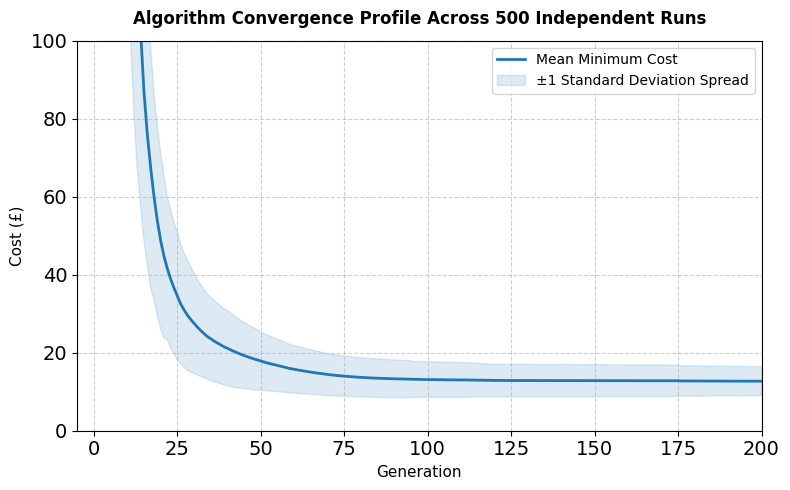

In [243]:
min_cost = np.min(final_costs)
max_cost = np.max(final_costs)
mean_cost = np.mean(final_costs)
std_cost = np.std(final_costs)

print(f"Minimum Achieved Cost:        £{min_cost:.4f}")
print(f"Maximum Achieved Cost:        £{max_cost:.4f}")
print(f"Global Mean Cost (mu):        £{mean_cost:.4f}")
print(f"Standard Deviation (sigma):   £{std_cost:.6f}")

avg_convergence = np.mean(convergence_history, axis=0)
std_convergence = np.std(convergence_history, axis=0)
generations = np.arange(0, NGEN + 1)

plt.figure(figsize=(8, 5))
plt.plot(generations, avg_convergence, color='#1f77b4', lw=2, label='Mean Minimum Cost')
plt.fill_between(generations, 
                 avg_convergence - std_convergence, 
                 avg_convergence + std_convergence, 
                 color='#1f77b4', alpha=0.15, label='±1 Standard Deviation Spread')

plt.title('Algorithm Convergence Profile Across 500 Independent Runs', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Generation', fontsize=11)
plt.ylabel('Cost (£)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)

plt.xlim(-5, 200) 
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('system_convergence_profile.png', dpi=300)
plt.show()

## Sensitivity to Changes in Constraints

In [247]:
FINAL_TOURNSIZE = 5
FINAL_CX_ALPHA = 1.0
FINAL_CX_PB = 0.8
FINAL_MUT_PB = 0.2
SIGMA = 0.2
INDPB = 0.16
MU = 100
LAMBDA = 200
NGEN = 200       
NUM_RUNS = 30 


creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("attr_float", random.uniform, 0, 5)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=6)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("select", tools.selTournament, tournsize=FINAL_TOURNSIZE)
toolbox.register("mate", tools.cxBlend, alpha=FINAL_CX_ALPHA)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=SIGMA, indpb=INDPB)
toolbox.register("evaluate", evalDiet) 

# Food,Cost,Protein,Fat,Carbohydrate,Calories
data = [
    ["Bread",2.0,4.0,1.0,15.0,90],

    ["Milk",3.5,8.0,5.0,11.7,120],

    ["Cheese",8.0,7.0,9.0,0.4,106],

    ["Potato",1.5,1.3,0.1,22.6,97],

    ["Fish",11.0,8.0,7.0,0.0,130],

    ["Yoghurt",1.0,9.2,1.0,17.0,180],
]

# Constraints increased
CALORIES_MIN = 300
PROTEIN_MAX = 10
CARBS_MIN = 10
FAT_MIN = 8
FISH_MIN = 0.5
MILK_MAX = 1.0

COSTS    = np.array([row[1] for row in data])
PROTEIN  = np.array([row[2] for row in data])
FAT      = np.array([row[3] for row in data])
CARBS    = np.array([row[4] for row in data])
CALORIES = np.array([row[5] for row in data])

scenarios = {
    "Relaxed (-10%)": {
        "CALORIES_MIN": 300 * 0.90,  
        "PROTEIN_MAX":  10 * 1.10,   
        "CARBS_MIN":    10 * 0.90,
        "FAT_MIN":       8 * 0.90,
        "FISH_MIN":    0.5 * 0.90,
        "MILK_MAX":    1.0 * 1.10
    },
    "Baseline": {
        "CALORIES_MIN": 300,
        "PROTEIN_MAX":  10,
        "CARBS_MIN":    10,
        "FAT_MIN":       8,
        "FISH_MIN":    0.5,
        "MILK_MAX":    1.0
    },
    "Tightened (+10%)": {
        "CALORIES_MIN": 300 * 1.10,  
        "PROTEIN_MAX":  10 * 0.90,   
        "CARBS_MIN":    10 * 1.10,
        "FAT_MIN":       8 * 1.10,
        "FISH_MIN":    0.5 * 1.10,
        "MILK_MAX":    1.0 * 0.90
    }
}

results_data = {"Relaxed (-10%)": [], "Baseline": [], "Tightened (+10%)": []}
experimental_seeds = [random.randint(10000, 99999) for _ in range(NUM_RUNS)]

# --- MAIN EXPERIMENTAL RUN LOOP ---
for name, target_bounds in scenarios.items():
    print(f"Modifying global variables and running scenario: {name}...")
    
    # Overwrite the global states right before the runs execute
    CALORIES_MIN = target_bounds["CALORIES_MIN"]
    PROTEIN_MAX  = target_bounds["PROTEIN_MAX"]
    CARBS_MIN    = target_bounds["CARBS_MIN"]
    FAT_MIN      = target_bounds["FAT_MIN"]
    FISH_MIN     = target_bounds["FISH_MIN"]
    MILK_MAX     = target_bounds["MILK_MAX"]
    
    for seed in experimental_seeds:
        random.seed(seed)
        np.random.seed(seed)
        
        pop = toolbox.population(n=MU)
        final_pop, _ = algorithms.eaMuPlusLambda(
            pop, toolbox, mu=MU, lambda_=LAMBDA, 
            cxpb=FINAL_CX_PB, mutpb=FINAL_MUT_PB, ngen=NGEN, 
            verbose=False
        )
        
        best_ind = tools.selBest(final_pop, 1)[0]
        results_data[name].append(best_ind.fitness.values[0])

# --- EXPORT DATA AND RENDER BOXPLOT ---
df_sensitivity = pd.DataFrame(results_data)
df_sensitivity.to_csv("constraint_sensitivity_results.csv", index=False)

/Users/elijah/uni/year4/EVAC/EVAC/.venv/lib/python3.14/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/Users/elijah/uni/year4/EVAC/EVAC/.venv/lib/python3.14/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


Modifying global variables and running scenario: Relaxed (-10%)...
Modifying global variables and running scenario: Baseline...
Modifying global variables and running scenario: Tightened (+10%)...


[Relaxed (-10%)]
  Mean Cost:         £10.1233
  Std Deviation:     £0.2854
  Min Achieved Cost: £9.8825
  Max Achieved Cost: £11.4467
[Baseline]
  Mean Cost:         £13.7435
  Std Deviation:     £8.8541
  Min Achieved Cost: £12.0876
  Max Achieved Cost: £60.6224
[Tightened (+10%)]
  Mean Cost:         £145.6111
  Std Deviation:     £12.4855
  Min Achieved Cost: £139.3189
  Max Achieved Cost: £184.5137


/var/folders/52/69f49r_s2h586mmww_9jwkrc0000gn/T/ipykernel_77394/2206340639.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot([df_sensitivity["Relaxed (-10%)"],


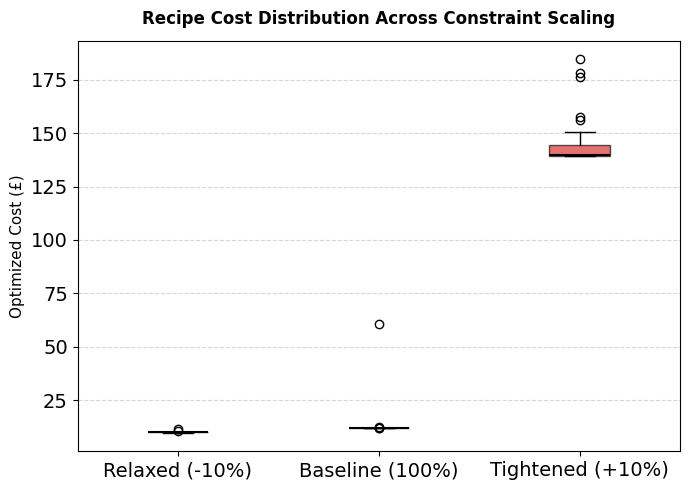

In [ ]:
for col in df_sensitivity.columns:
    print(f"[{col}]")
    print(f"  Mean Cost:         £{df_sensitivity[col].mean():.4f}")
    print(f"  Std Deviation:     £{df_sensitivity[col].std():.4f}")
    print(f"  Min Achieved Cost: £{df_sensitivity[col].min():.4f}")
    print(f"  Max Achieved Cost: £{df_sensitivity[col].max():.4f}")
    
# Generate Boxplot
plt.figure(figsize=(7, 5))
box = plt.boxplot([df_sensitivity["Relaxed (-10%)"], 
                   df_sensitivity["Baseline"], 
                   df_sensitivity["Tightened (+10%)"]], 
                  labels=["Relaxed (-10%)", "Baseline (100%)", "Tightened (+10%)"],
                  patch_artist=True,
                  medianprops=dict(color="black", lw=1.5))

colors = ['#2ca02c', '#1f77b4', '#d62728']  # Academic Green, Blue, Red
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

plt.title("Recipe Cost Distribution Across Constraint Scaling", fontsize=12, fontweight="bold", pad=12)
plt.ylabel("Optimized Cost (£)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5, axis='y')
plt.tight_layout()
plt.show()